# Logistic Regression: Predicting if a person would buy life insurnace based on the person's age

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [3]:
df = pd.read_csv("datasets/insurance_data.csv")
df.head()

,age,bought_insurance
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1


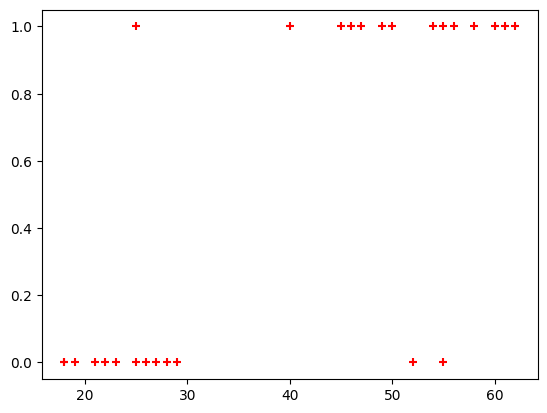

In [4]:
plt.scatter(df.age,df.bought_insurance,marker='+',color='red')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.bought_insurance,train_size=0.8)

In [7]:
len(X_train), len(X_test), len(y_train), len(y_test)

(21, 6, 21, 6)

In [8]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [9]:
model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


In [10]:
X_test

,age
3,52
0,22
24,50
6,55
12,27
19,18


In [11]:
y_predicted = model.predict(X_test)

In [12]:
model.predict_proba(X_test)

array([[1.84519944e-03, 9.98154801e-01],
       [9.48573016e-01, 5.14269843e-02],
       [3.40382261e-03, 9.96596177e-01],
       [7.35567302e-04, 9.99264433e-01],
       [7.99008605e-01, 2.00991395e-01],
       [9.84365921e-01, 1.56340785e-02]])

In [13]:
model.score(X_test,y_test)

0.6666666666666666

In [14]:
y_predicted

array([1, 0, 1, 1, 0, 0])

In [15]:
X_test

,age
3,52
0,22
24,50
6,55
12,27
19,18


Determine the value of m and b in y=m*x + b

In [16]:
model.coef_, model.intercept_

(array([[0.30693723]]), array([-9.6674147]))

### Using sigmoid function now and do the math with hand

In [17]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [18]:
def prediction_function(age):
    m = model.coef_[0][0]
    b = model.intercept_[0]
    z = m * age +b 
    y = sigmoid(z)
    return y

In [19]:
age = 35
prediction_function(age)

0.7456202472478166

0.168 is less than 0.5 which means person with 35 age will *not* buy insurance

In [20]:
age = 43
prediction_function(age)

0.971553908255849

A person with 43 years is more likely to buy insurance

## Exercise

Download employee retention dataset from here: https://www.kaggle.com/giripujar/hr-analytics. 
1. Now do some exploratory data analysis to figure out which variables have direct and clear impact on employee retention (i.e. whether they leave the company or continue to work)
2. Plot bar charts showing impact of employee salaries on retention
3. Plot bar charts showing corelation between department and employee retention
4. Now build logistic regression model using variables that were narrowed down in step 1
5. Measure the accuracy of the model

In [21]:
dfr = pd.read_csv("datasets/HR_comma_sep.csv")
dfr.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### 1-Exploratory data analysis

In [22]:
dfr.describe()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [23]:
dfr.groupby('left').mean(numeric_only=True)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years
left,,,,,,,
0,0.666810,0.715473,3.786664,199.060203,3.380032,0.175009,0.026251
1,0.440098,0.718113,3.855503,207.419210,3.876505,0.047326,0.005321


From the averaging over groups who left and those that didn't we observe the following:

*  Satisfaction level is smaller for employees who left the firm compared to those who stayed.
*  Average monthly hours of work for those who left is higher than those who stayed.
*  Number of projects for employees that left the firm was larger than those who were retained.
*  Employees that received promotion are likely to be keep in the firm compared to those who did received the promotion.

### 2- Impact of employees salary on retention

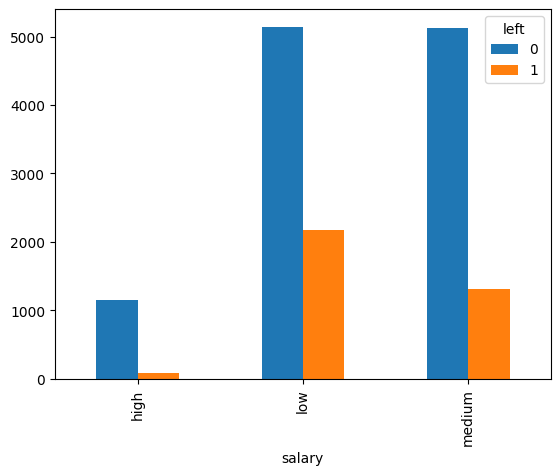

In [24]:
pd.crosstab(dfr.salary, dfr.left).plot(kind='bar')
plt.show()

### 3- Impact of employees department on retention

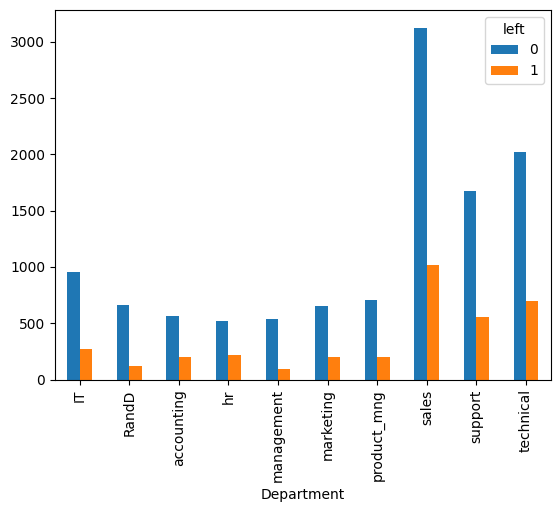

In [25]:
pd.crosstab(dfr.Department, dfr.left).plot(kind='bar')
plt.show()

### 4-Logistic Model for Retention

Using the exploration analysis done above we selected the following variables of interest.

In [26]:
dfr_small = dfr[['satisfaction_level', 'average_montly_hours', 'number_project','promotion_last_5years','salary']]
dfr_small.head()

,satisfaction_level,average_montly_hours,number_project,promotion_last_5years,salary
0,0.38,157,2,0,low
1,0.80,262,5,0,medium
2,0.11,272,7,0,medium
3,0.72,223,5,0,low
4,0.37,159,2,0,low


Next, we use one-hot-encoding on the categorical variables salary and department to convert it to numbers.

In [27]:
salary_dummies = pd.get_dummies(dfr_small.salary, prefix="salary")

In [28]:
dfr_small_dummies = pd.concat([dfr_small, salary_dummies], axis='columns')

In [29]:
dfr_small_dummies.head()

,satisfaction_level,average_montly_hours,number_project,promotion_last_5years,salary,salary_high,salary_low,salary_medium
0,0.38,157,2,0,low,False,True,False
1,0.80,262,5,0,medium,False,False,True
2,0.11,272,7,0,medium,False,False,True
3,0.72,223,5,0,low,False,True,False
4,0.37,159,2,0,low,False,True,False


In [30]:
dfr_small_dummies.drop('salary', axis="columns", inplace=True)
dfr_small_dummies.head()

,satisfaction_level,average_montly_hours,number_project,promotion_last_5years,salary_high,salary_low,salary_medium
0,0.38,157,2,0,False,True,False
1,0.80,262,5,0,False,False,True
2,0.11,272,7,0,False,False,True
3,0.72,223,5,0,False,True,False
4,0.37,159,2,0,False,True,False


In [31]:
X = dfr_small_dummies
y = dfr.left

In [32]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y , train_size=0.3)

In [33]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [34]:
model.fit(X_train, y_train)
print("model trained successfully")

model trained successfully


In [35]:
model.predict(X_test)

array([0, 0, 0, ..., 0, 0, 0], shape=(10500,))

In [36]:
model.score(X_test, y_test)

0.788952380952381